# Введение в регрессию 1
Давайте рассмотрим нарушения предпосылок Гаусса-Маркова на примере симулированных данных.

In [ ]:
# Подключим нужные для базовых операций библиотеки
import seaborn as sb
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# Подключим пакеты для использования OLS метода и тестов
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 

# Подгрузим полезные функции
from maths.my_utils import *

# Сделаем автоподгрузку всех изменений при перепрогонке ячейки
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Неверный тип зависимостей
Сгенерируем несколько кейсов, когда зависимость между факторами и таргетом в действительности нелинейная, но мы воспринимаем ее как линейную и применяем OLS алгоритм.

In [19]:
# Определим параметры выборки для задачи преобразования факторов
# Создадим удобный словарь, чтобы передавать его в функцию
dist_params = dict(

    # Зададим параметры распределения факторов
    x1_mean = 5,
    x1_width = 2.8,
    x2_mean = 20,
    x2_std = 5,
    
    # Зададим параметры распределения ошибки
    e_mean = 0,
    e_std = 300,

    # Укажем размер выборки
    N = 2000,

    # Зададим действительные параметры модели
    beta0 = 500,
    beta1 = 6.7,
    beta2 = 2.3
)

# Установим стартовую точку для алгоритма генерации случайных чисел
RANDOM_SEED = 42

In [20]:
# Сгенерируем датасет с нормальным распределением в регрессоре
dt_linearity = gen_data(y_type='linearity', params=dist_params, seed=RANDOM_SEED)

display(dt_linearity)

NameError: name 'gen_data' is not defined

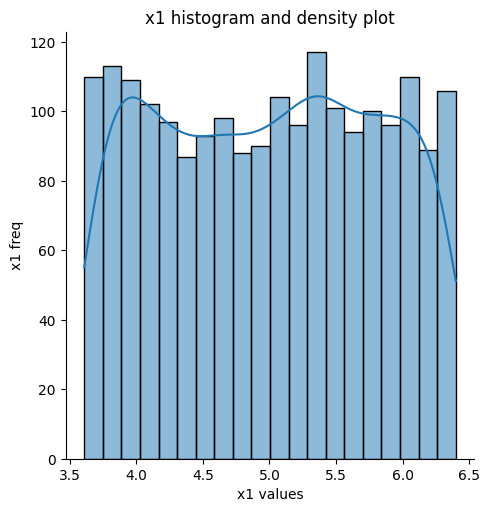

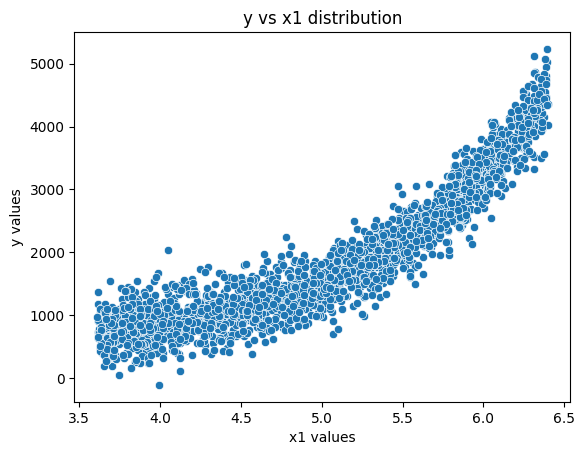

In [4]:
# Отрисуем факторы
plot_data(dt_linearity, target='y', feature_names=['x1'], plot_type='EDA')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     9262.
Date:                Thu, 13 Feb 2025   Prob (F-statistic):               0.00
Time:                        19:42:39   Log-Likelihood:                -15089.
No. Observations:                2000   AIC:                         3.018e+04
Df Residuals:                    1998   BIC:                         3.019e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4146.3620     63.337    -65.465      0.0

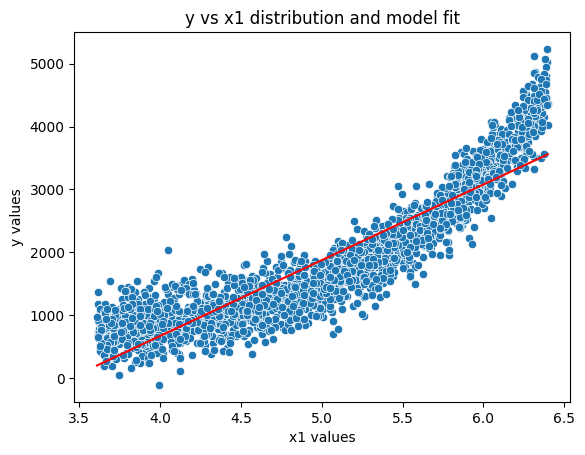

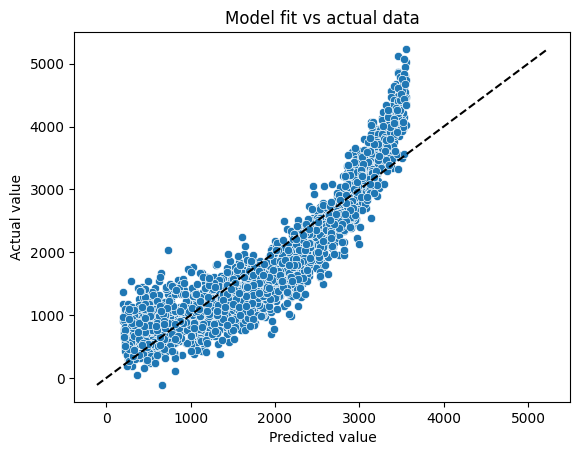

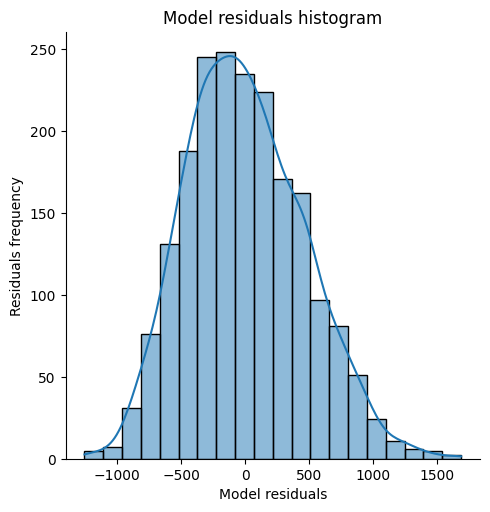

,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.0,False,0.991704,,,not gaussian distribution
1,Epps-Pulley test,0.95,0.05,-,-,-,-,False,count more than 1000
2,D'Agostino's K-squared test,0.95,0.05,0.0,False,36.985933,,,not gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,4.334738,0.785,False,not gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.016598,False,0.034525,,,not gaussian distribution
5,Lilliefors test,0.95,0.05,0.001,False,0.034528,,,not gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.010761,False,0.730129,,,not gaussian distribution
7,Chi-squared test,0.95,0.05,0.0,False,375299968947541311488.0,,,not gaussian distribution
8,Jarque–Bera test,0.95,0.05,0.0,False,38.729458,,,not gaussian distribution
9,skewtest,0.95,0.05,0.0,False,6.018359,,,not gaussian distribution


In [6]:
# Обучим модель c неверной спецификацией и выведем результаты
# Здесь мы берем в качестве фактора сырые значения x1
dt_linearity, model_linearity = train_model(dt_linearity, target='y', feature_names=['x1'], show_results=True, pairwise=True, return_norm_tests=True)

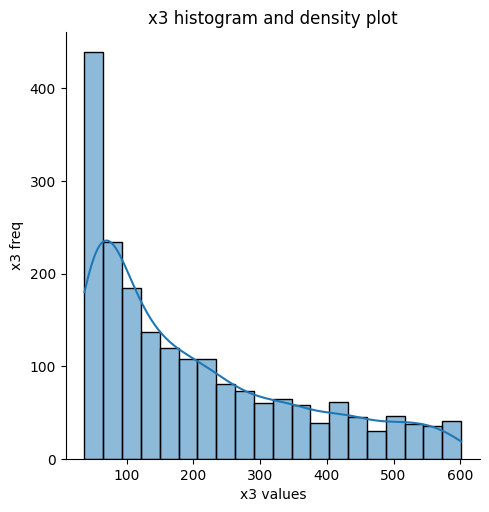

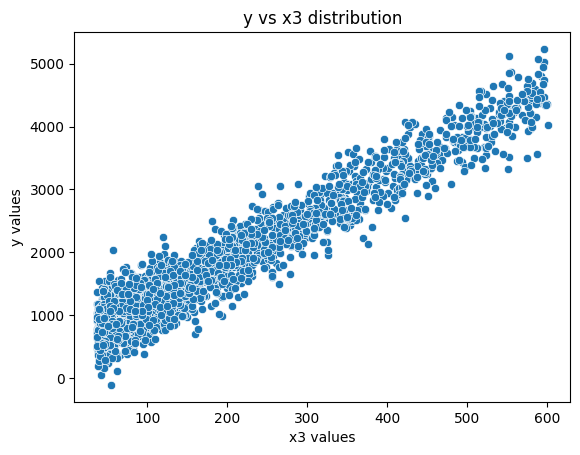

In [10]:
# Отрисуем факторы
plot_data(dt_linearity, target='y', feature_names=['x3'], plot_type='EDA')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                 2.482e+04
Date:                Thu, 13 Feb 2025   Prob (F-statistic):               0.00
Time:                        19:44:17   Log-Likelihood:                -14221.
No. Observations:                2000   AIC:                         2.845e+04
Df Residuals:                    1998   BIC:                         2.846e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        505.2702     10.904     46.339      0.0

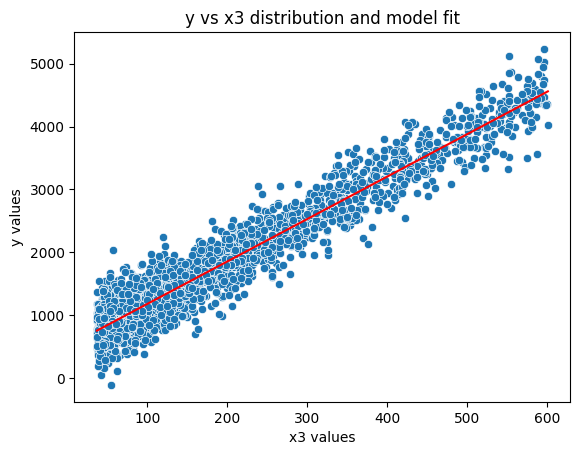

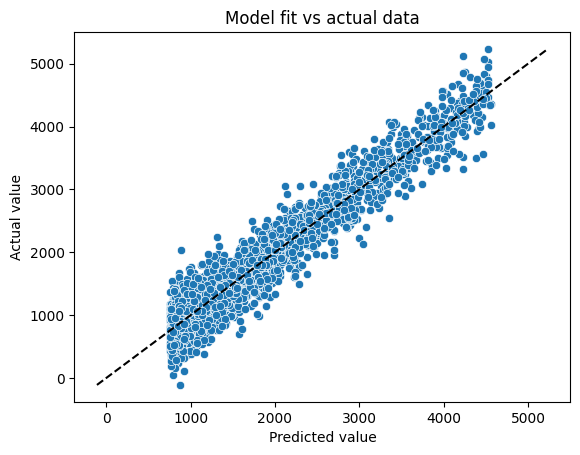

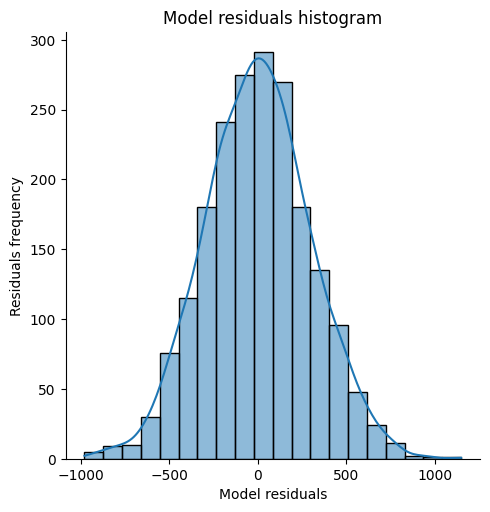

,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.89688,True,0.999487,,,gaussian distribution
1,Epps-Pulley test,0.95,0.05,-,-,-,-,False,count more than 1000
2,D'Agostino's K-squared test,0.95,0.05,0.708933,True,0.687987,,,gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,0.208601,0.785,True,gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.938226,True,0.011852,,,gaussian distribution
5,Lilliefors test,0.95,0.05,0.720605,True,0.011904,,,gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.9783,True,0.029343,,,gaussian distribution
7,Chi-squared test,0.95,0.05,0.0,False,140737488355327983616.0,,,not gaussian distribution
8,Jarque–Bera test,0.95,0.05,0.738401,True,0.606535,,,gaussian distribution
9,skewtest,0.95,0.05,0.574912,True,0.560831,,,gaussian distribution


In [7]:
# Обучим модель c верной спецификацией и выведем результаты
dt_linearity, model_linearity = train_model(dt_linearity, target='y', feature_names=['x3'], show_results=True, pairwise=True, return_norm_tests=True)

## 2. Пропущенная переменная
Сгенерируем несколько кейсов, когда мы пропустили переменную и применяем OLS алгоритм.

In [8]:
# Определим параметры выборки для задачи пропущенной переменной
# Создадим удобный словарь, чтобы передавать его в функцию
dist_params = dict(

    # Зададим параметры распределения факторов
    x1_mean = 25.0,
    x1_std = 10.3,
    x2_mean = 20.0,
    x2_std = 5.0,
    x3_mean = 30.0,
    x3_std = 8.0,
    corr_12 = 0.0,
    corr_23 = 0.0,
    corr_13 = 0.6,
    
    # Зададим параметры распределения ошибки
    e_mean = 0.0,
    e_std = 30.0,

    # Укажем размер выборки
    N = 2000,

    # Зададим действительные параметры модели
    beta0 = 500.0,
    beta1 = 6.7,
    beta2 = 2.3,
    beta3 = -17.7
)

# Установим стартовую точку для алгоритма генерации случайных чисел
RANDOM_SEED = 42

,x1,x2,x3,e,y
0,19.692193,16.761557,27.418197,-33.422441,151.764749
1,9.310879,21.170685,21.197736,-18.927925,216.947620
2,11.849820,22.347372,16.157533,-28.261806,316.542614
3,18.238207,22.328649,28.638072,-16.439875,150.218123
4,16.717643,28.624589,37.358696,-6.424509,10.171325
...,...,...,...,...,...
1995,28.132897,19.795376,37.418537,66.295670,138.007341
1996,19.510030,17.311159,29.013193,9.809835,166.809178
1997,18.908264,17.406035,32.669227,-25.053735,63.420201
1998,17.043469,14.236759,23.589215,49.587392,278.994079


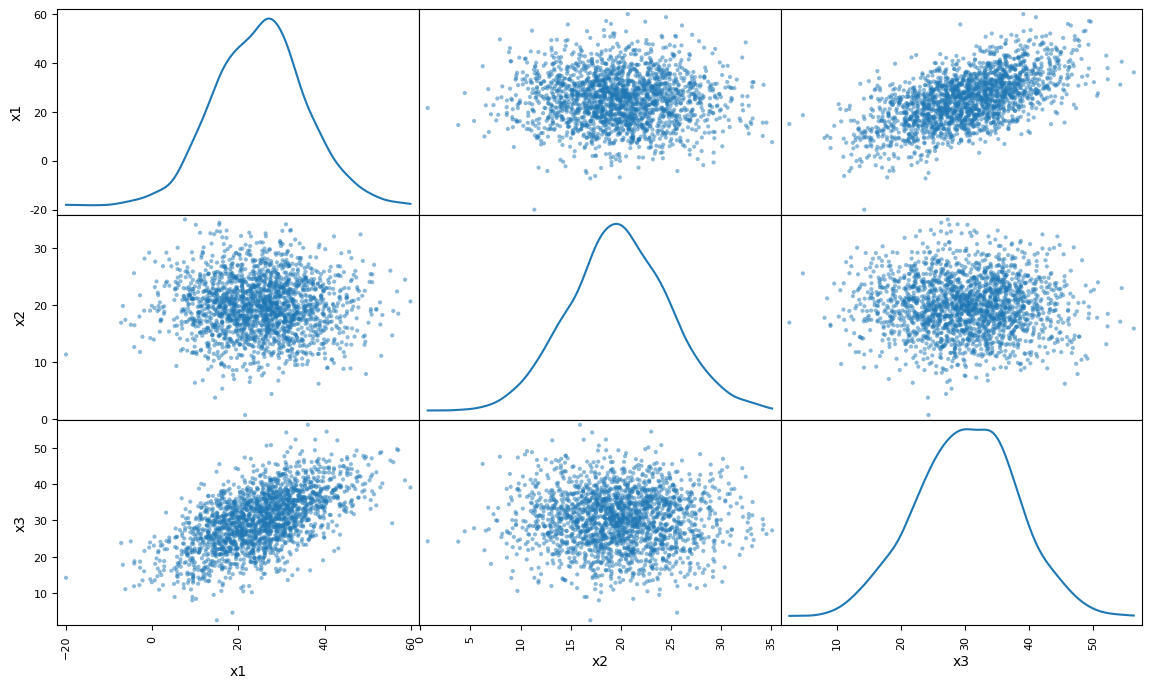

In [9]:
# Сгенерируем датасет с нормальным распределением в регрессоре
dt_missing_var = gen_data(y_type='multivariate', params=dist_params, seed=RANDOM_SEED)

display(dt_missing_var)

# Посмотрим на корреляции глазами
pd.plotting.scatter_matrix(dt_missing_var[['x1', 'x2', 'x3']], figsize = (14,8), diagonal = 'kde');

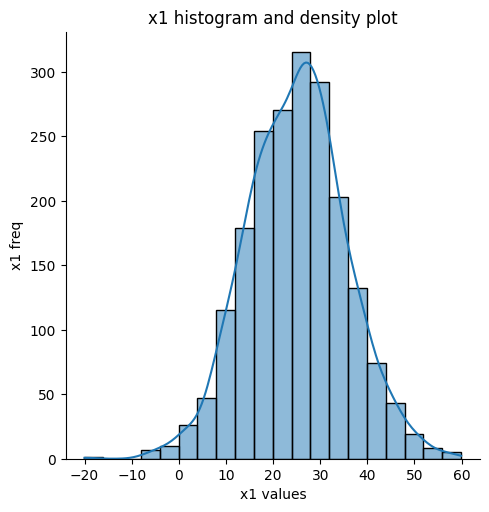

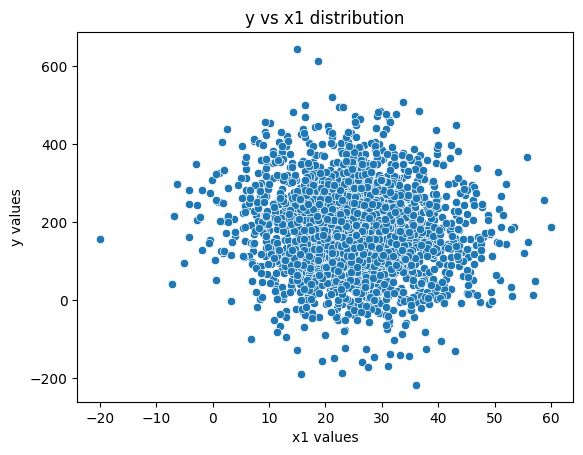

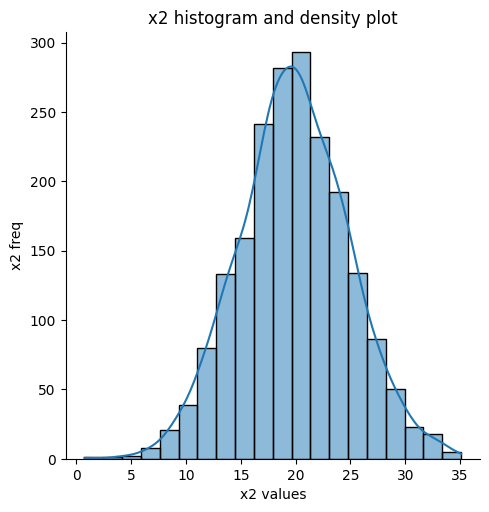

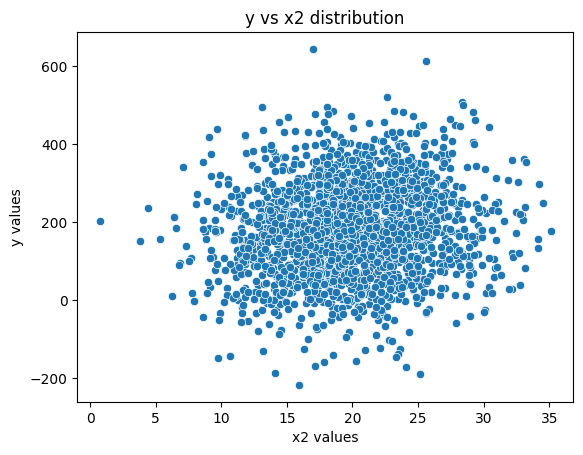

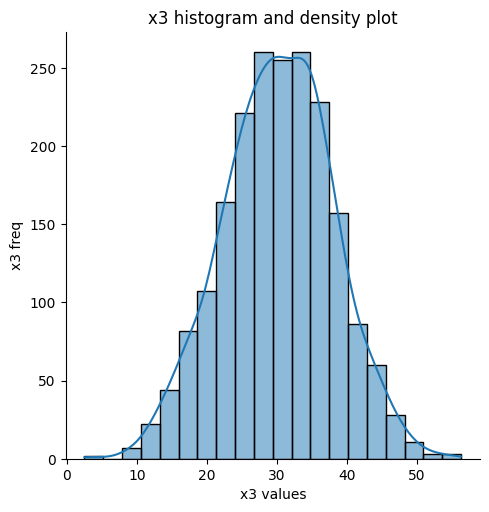

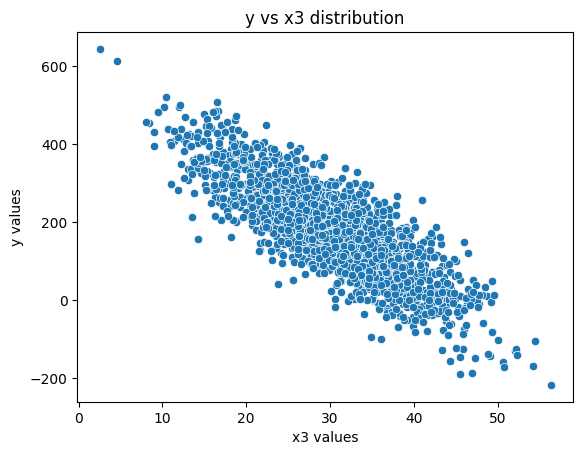

In [10]:
# Отрисуем факторы
plot_data(dt_missing_var, target='y', feature_names=['x1', 'x2', 'x3'], plot_type='EDA')

### Обучение модели с неверной спецификацией
Теперь мы решем построить линейную модель, чтобы найти взаимосвязь между нашими факторами x1, x2 и таргетом y

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     21.19
Date:                Thu, 13 Feb 2025   Prob (F-statistic):           7.86e-10
Time:                        20:09:21   Log-Likelihood:                -12341.
No. Observations:                2000   AIC:                         2.469e+04
Df Residuals:                    1997   BIC:                         2.470e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        153.9906     12.471     12.348      0.0

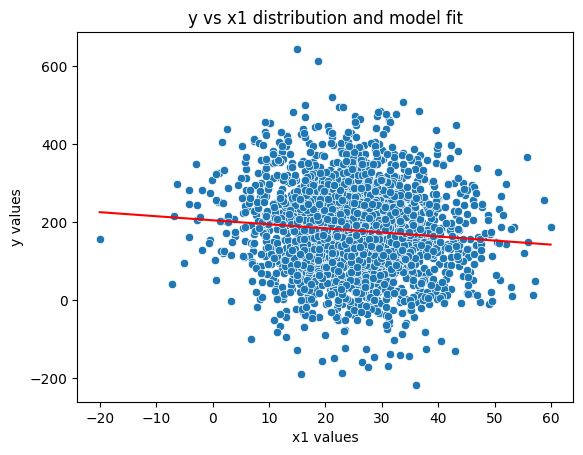

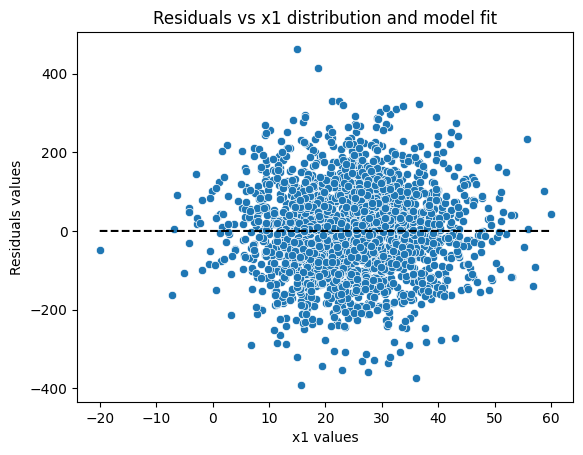

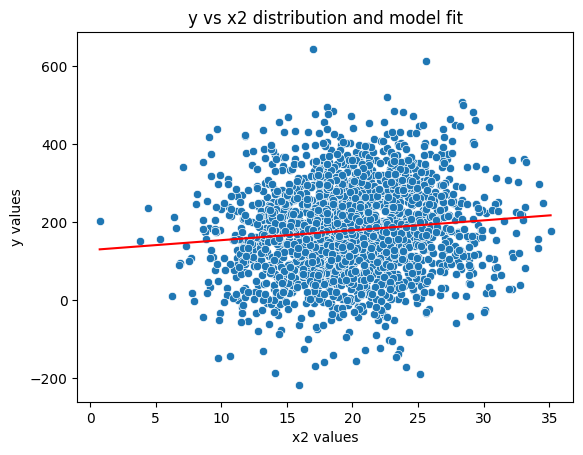

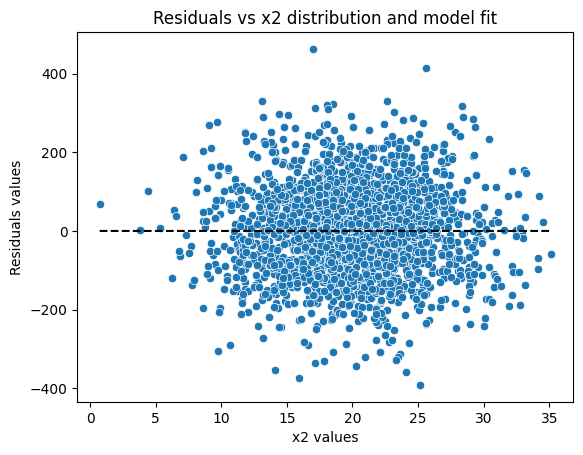

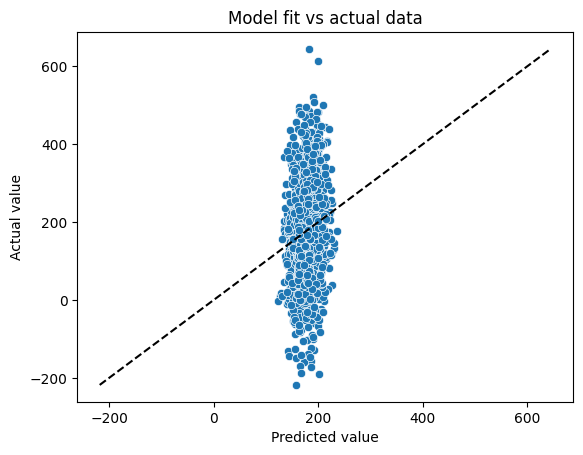

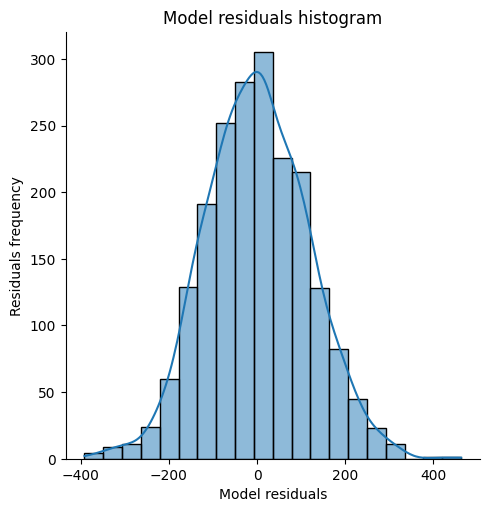

/Users/nimalykhin/Library/Python/3.9/lib/python/site-packages/scipy/stats/_stats_py.py:8022: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs_float - f_exp)**2 / f_exp


,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.294423,True,0.998957,,,gaussian distribution
1,Epps-Pulley test,0.95,0.05,-,-,-,-,False,count more than 1000
2,D'Agostino's K-squared test,0.95,0.05,0.33373,True,2.194847,,,gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,0.453486,0.785,True,gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.616307,True,0.016832,,,gaussian distribution
5,Lilliefors test,0.95,0.05,0.203256,True,0.016854,,,gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.793676,True,0.063236,,,gaussian distribution
7,Chi-squared test,0.95,0.05,0.0,False,inf,,,not gaussian distribution
8,Jarque–Bera test,0.95,0.05,0.348734,True,2.106889,,,gaussian distribution
9,skewtest,0.95,0.05,0.257508,True,1.1323,,,gaussian distribution


In [11]:
# Обучим модель и выведем результаты
dt_missing_var, model_missing_var = train_model(dt_missing_var, target='y', feature_names=['x1', 'x2'], show_results=True, return_norm_tests=True)

### Обучение модели с корректной спецификацией
Допустим, мы поигрались со различными спецификациями и нашли ту, которую считаем наиболее правильной для описания процесса

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     8822.
Date:                Thu, 13 Feb 2025   Prob (F-statistic):               0.00
Time:                        20:13:03   Log-Likelihood:                -9704.2
No. Observations:                2000   AIC:                         1.942e+04
Df Residuals:                    1996   BIC:                         1.944e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.6971      3.964    125.569      0.0

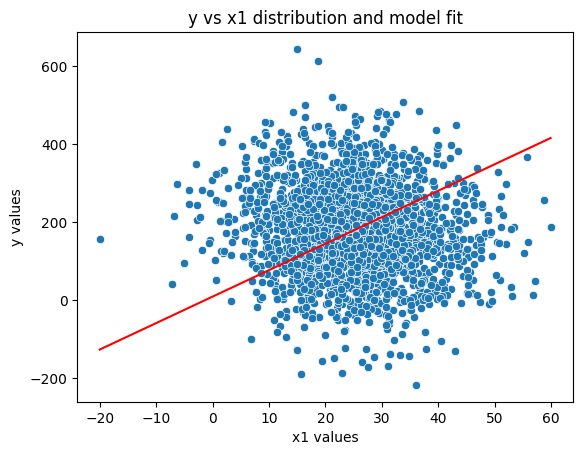

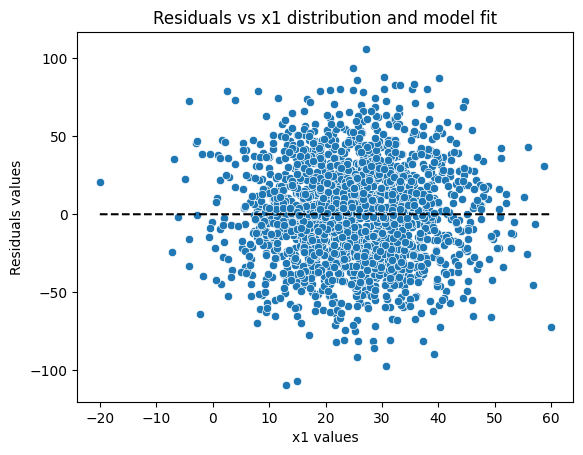

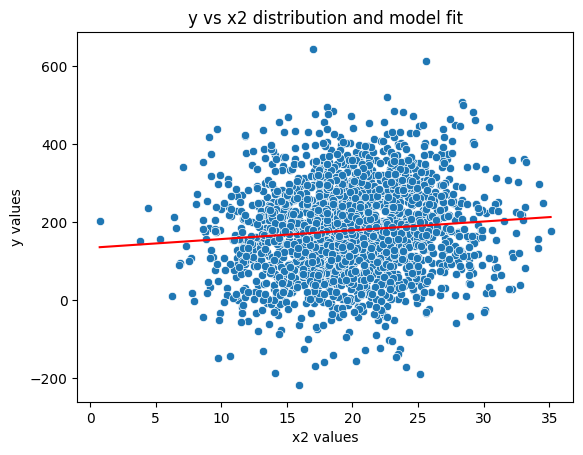

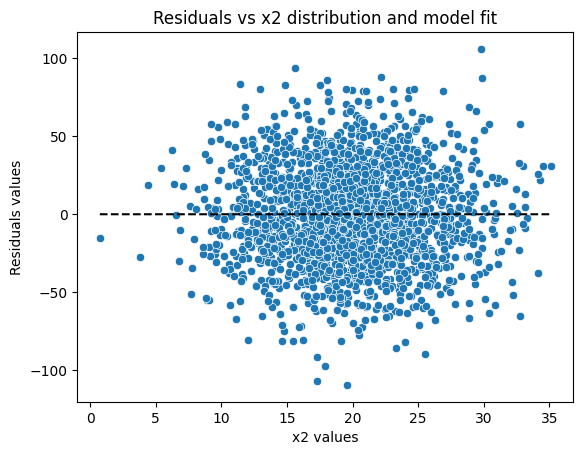

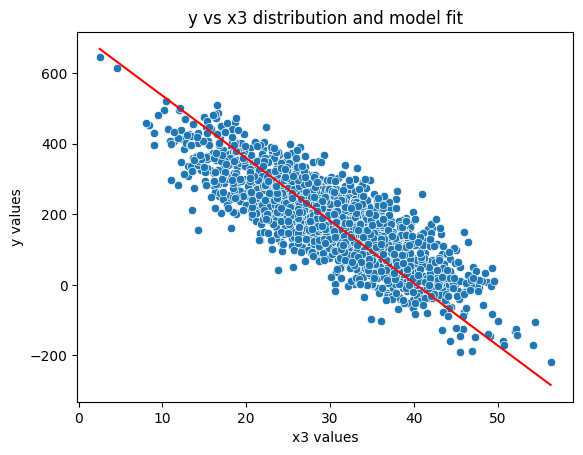

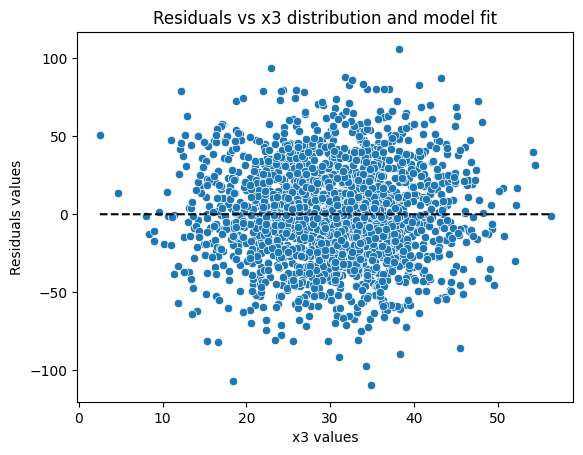

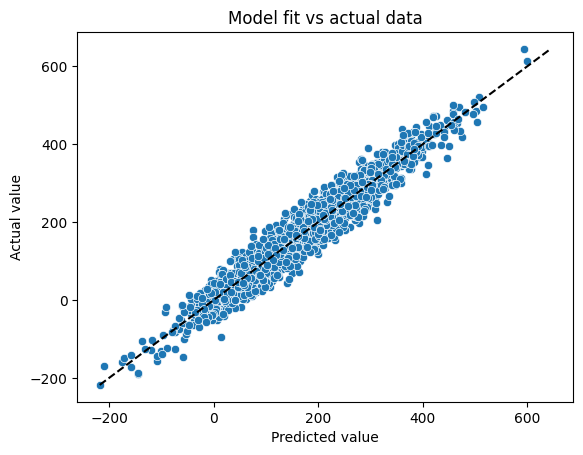

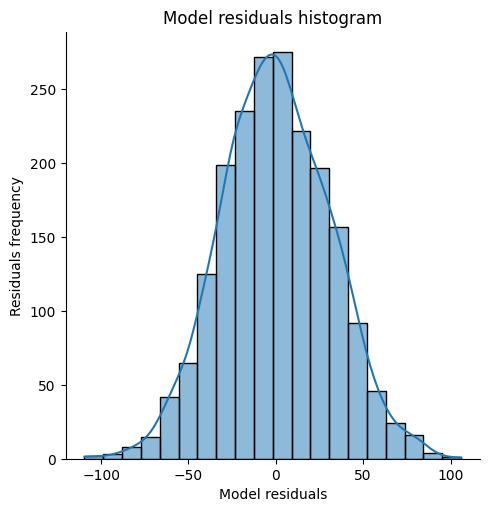

,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.635899,True,0.999264,,,gaussian distribution
1,Epps-Pulley test,0.95,0.05,-,-,-,-,False,count more than 1000
2,D'Agostino's K-squared test,0.95,0.05,0.724071,True,0.645731,,,gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,0.476538,0.785,True,gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.779323,True,0.014634,,,gaussian distribution
5,Lilliefors test,0.95,0.05,0.398343,True,0.01465,,,gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.662844,True,0.08512,,,gaussian distribution
7,Chi-squared test,0.95,0.05,1.0,True,-187649984473770688512.0,,,gaussian distribution
8,Jarque–Bera test,0.95,0.05,0.713611,True,0.674836,,,gaussian distribution
9,skewtest,0.95,0.05,0.433271,True,0.783607,,,gaussian distribution


In [13]:
# Обучим модель и выведем результаты
dt_missing_var, model_missing_var = train_model(dt_missing_var, target='y', feature_names=['x1', 'x2', 'x3'], show_results=True, return_norm_tests=True)

In [14]:
# Определим параметры выборки для задачи мультиколлинеарности
# Создадим удобный словарь, чтобы передавать его в функцию
dist_params = dict(

    # Зададим параметры распределения факторов
    x1_mean = 100.0,
    x1_std = 10.0,
    x2_mean = 20.0,
    x2_std = 5.0,
    x3_mean = 30.0,
    x3_std = 8.0,
    corr_12 = 0.4,
    corr_23 = 0.95,
    corr_13 = 0.3,
    
    # Зададим параметры распределения ошибки
    e_mean = 0.0,
    e_std = 100.0,

    # Укажем размер выборки
    N = 2000,

    # Зададим действительные параметры модели
    beta0 = 500.0,
    beta1 = -6.7,
    beta2 = 2.3,
    beta3 = 17.7
)

# Установим стартовую точку для алгоритма генерации случайных чисел
RANDOM_SEED = 42

,x1,x2,x3,e,y
0,95.042885,17.739813,28.249383,-111.408136,292.620183
1,85.597184,14.907688,22.209226,-63.093083,290.796767
2,90.059062,12.062322,16.305376,-94.206018,118.746772
3,92.960606,19.687457,29.043576,-54.799582,381.716793
4,88.302167,26.389591,37.867919,-21.415031,617.918673
...,...,...,...,...,...
1995,100.994012,24.493109,37.675529,220.985567,767.516710
1996,94.304555,18.836099,29.927487,32.699451,473.898480
1997,92.424000,21.099537,33.942420,-83.512450,446.556529
1998,93.425451,14.859513,24.741720,165.291305,511.446100


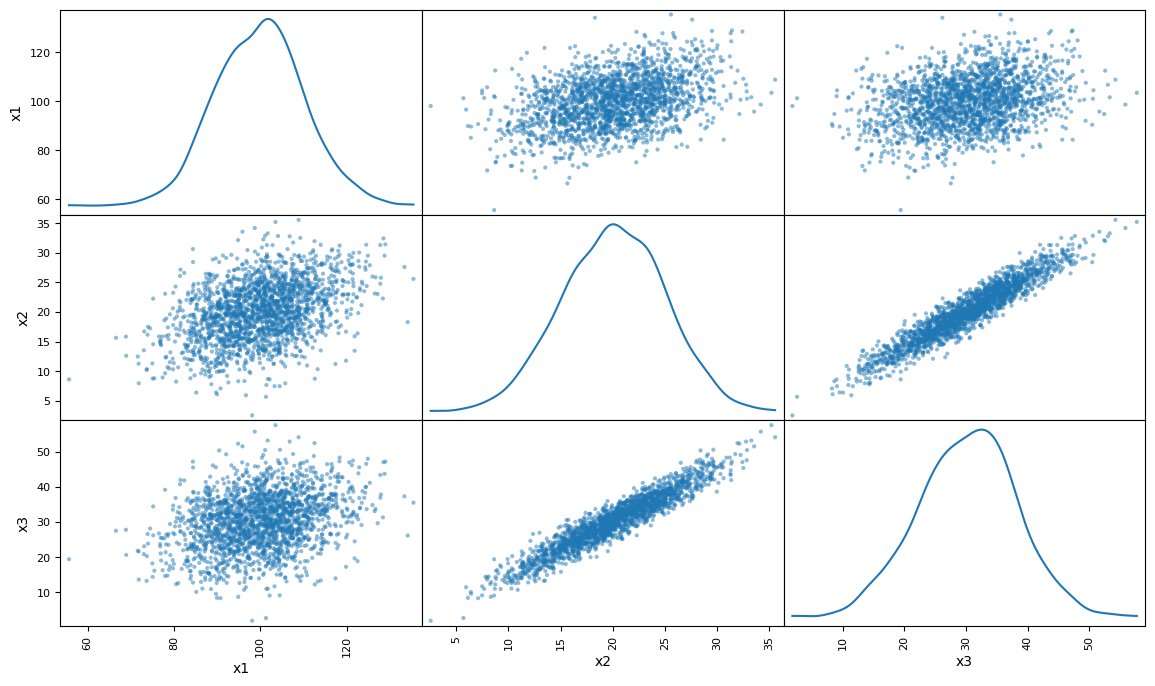

In [16]:
# Сгенерируем датасет с нормальным распределением в регрессоре
dt_collinearity = gen_data(y_type='multivariate', params=dist_params, seed=RANDOM_SEED)

display(dt_collinearity)

# Посмотрим на корреляции глазами
pd.plotting.scatter_matrix(dt_collinearity[['x1', 'x2', 'x3']], figsize = (14,8), diagonal = 'kde');

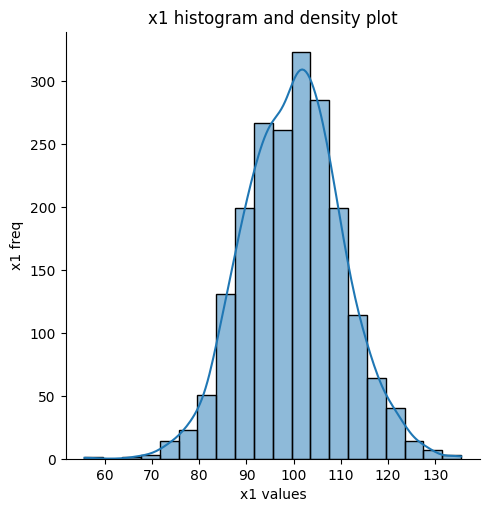

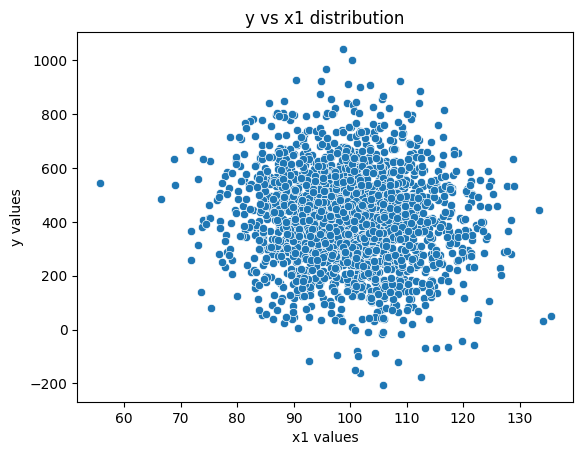

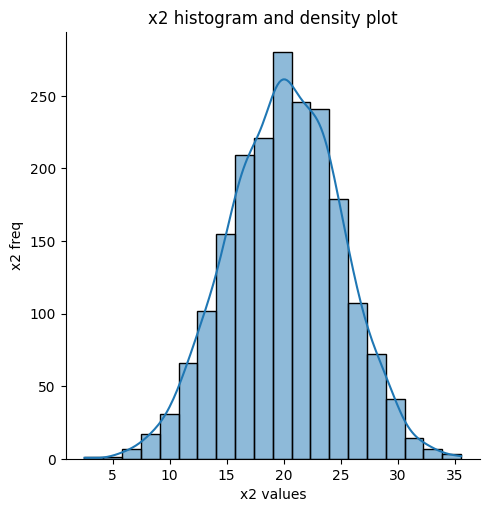

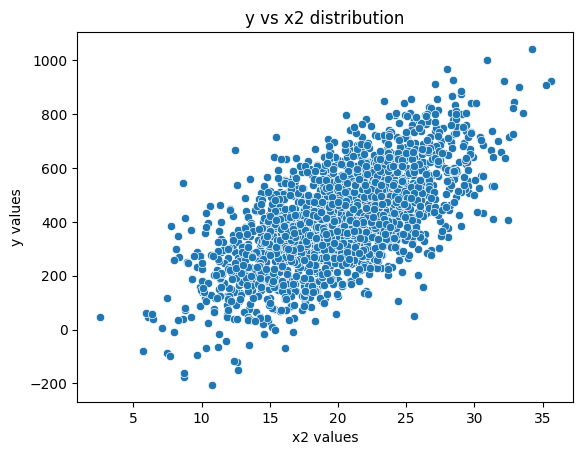

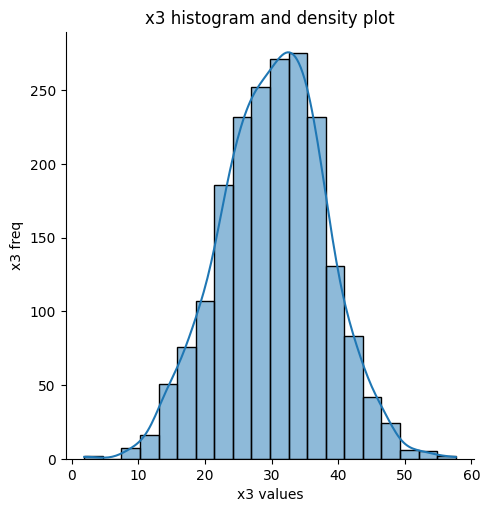

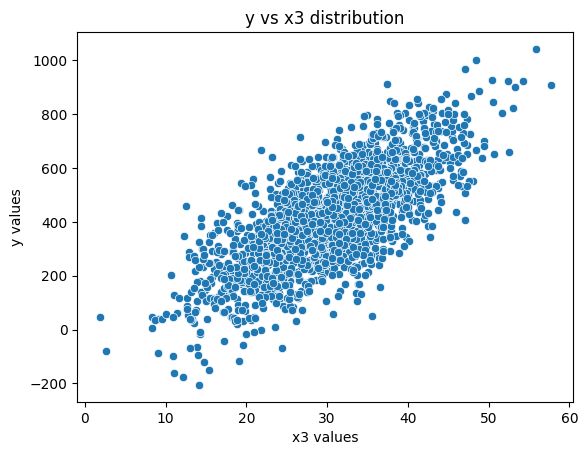

In [17]:
# Отрисуем факторы
plot_data(dt_collinearity, target='y', feature_names=['x1', 'x2', 'x3'], plot_type='EDA')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     1312.
Date:                Thu, 13 Feb 2025   Prob (F-statistic):               0.00
Time:                        20:39:06   Log-Likelihood:                -12112.
No. Observations:                2000   AIC:                         2.423e+04
Df Residuals:                    1996   BIC:                         2.425e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        462.3327     23.409     19.750      0.0

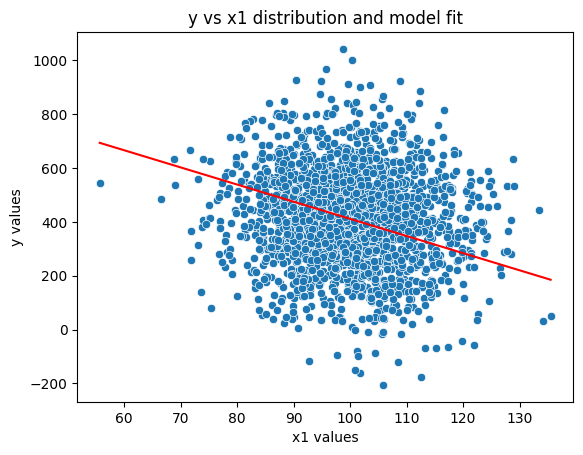

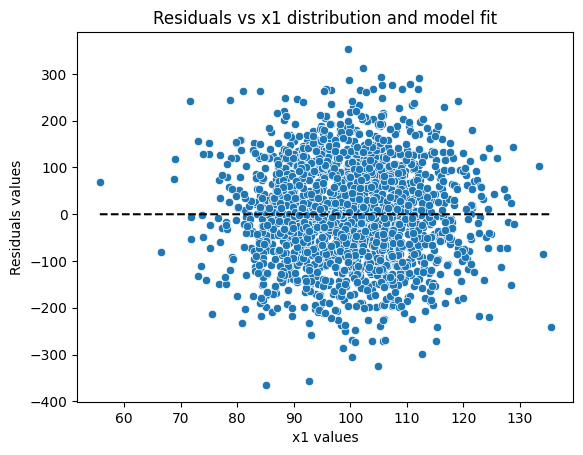

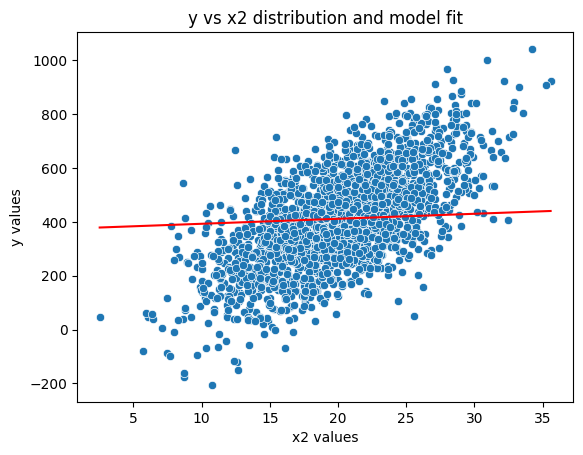

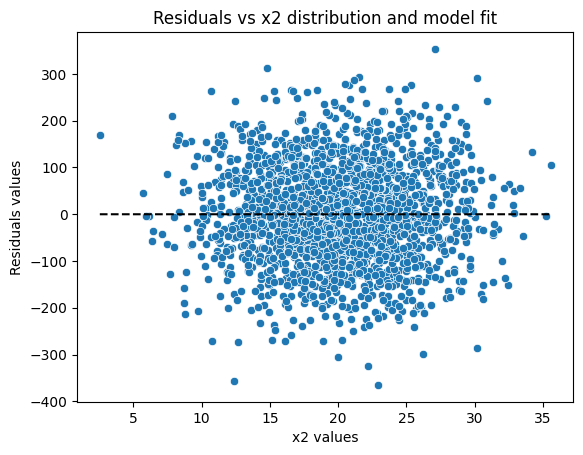

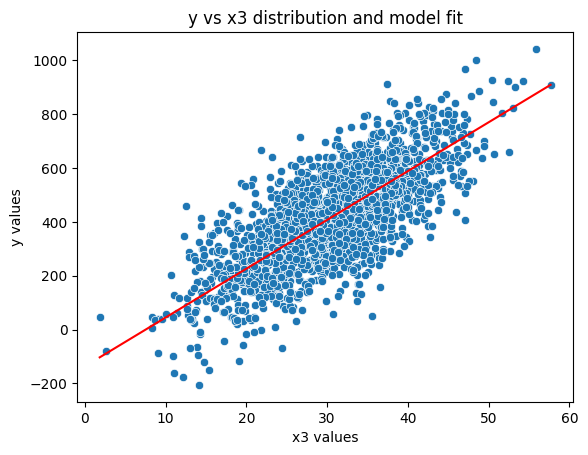

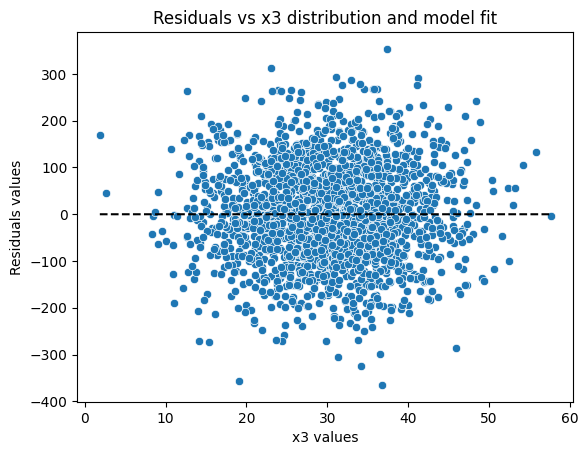

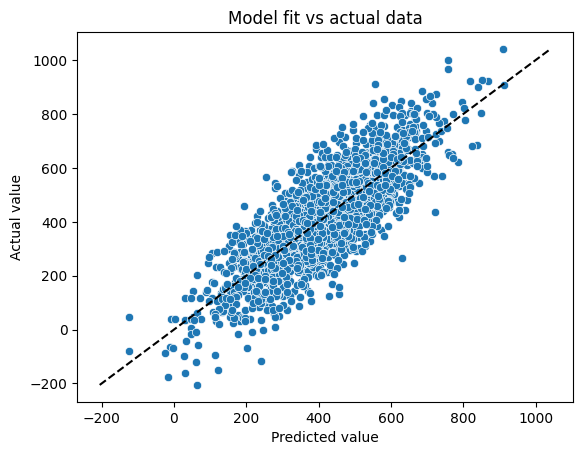

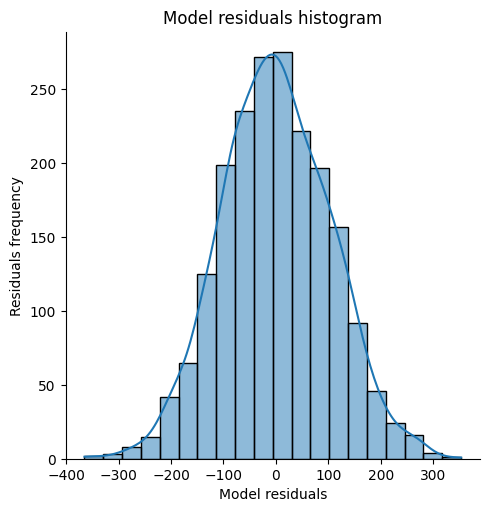

,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.635899,True,0.999264,,,gaussian distribution
1,Epps-Pulley test,0.95,0.05,-,-,-,-,False,count more than 1000
2,D'Agostino's K-squared test,0.95,0.05,0.724071,True,0.645731,,,gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,0.476538,0.785,True,gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.779323,True,0.014634,,,gaussian distribution
5,Lilliefors test,0.95,0.05,0.398343,True,0.01465,,,gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.662844,True,0.08512,,,gaussian distribution
7,Chi-squared test,0.95,0.05,0.0,False,160842843834660585472.0,,,not gaussian distribution
8,Jarque–Bera test,0.95,0.05,0.713611,True,0.674836,,,gaussian distribution
9,skewtest,0.95,0.05,0.433271,True,0.783607,,,gaussian distribution


In [18]:
# Обучим модель и выведем результаты
dt_collinearity, model_collinearity = train_model(dt_collinearity, target='y', feature_names=['x1', 'x2', 'x3'], show_results=True, return_norm_tests=True)

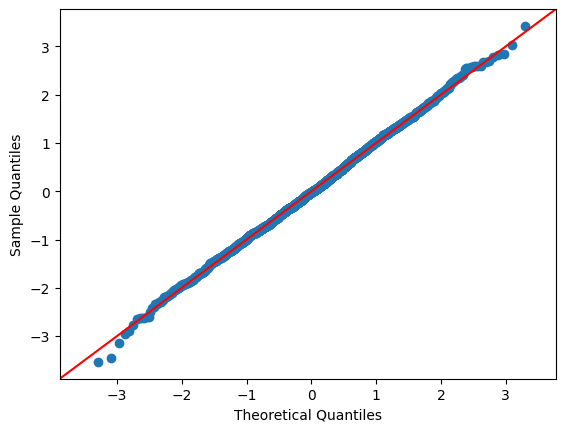

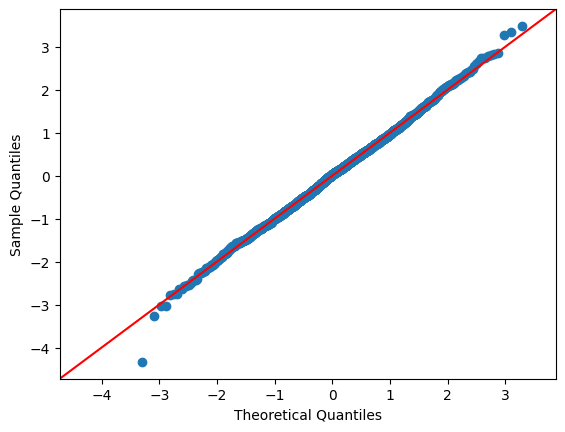

In [19]:
# Строим Q-Q plot для анализа остатков
sm.qqplot(model_collinearity.resid/ np.std(model_collinearity.resid), line='45');
plt.show()

# Пример "нормальной" ситуации
sm.qqplot((dt_collinearity['x1'] - np.mean(dt_collinearity['x1']))/ np.std(dt_collinearity['x1']), line='45');
plt.show()

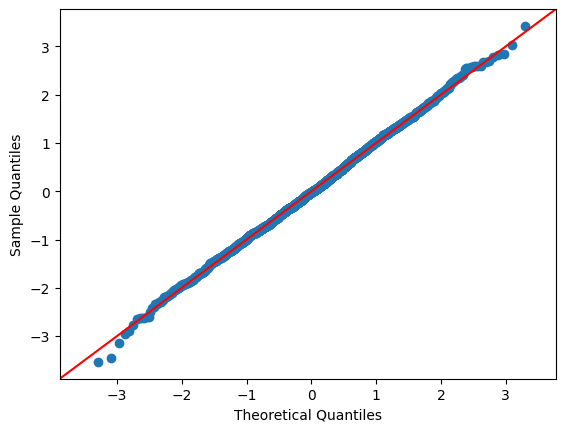

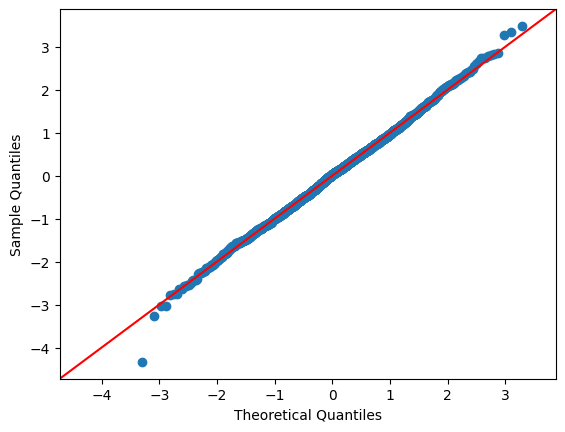

In [20]:
# Строим Q-Q plot для анализа остатков
sm.qqplot(model_collinearity.resid/ np.std(model_collinearity.resid), line='45');
plt.show()

# Пример "нормальной" ситуации
sm.qqplot((dt_collinearity['x1'] - np.mean(dt_collinearity['x1']))/ np.std(dt_collinearity['x1']), line='45');
plt.show()

In [21]:
# Рассчитываем VIF, используя пакет в Python
calc_VIF(dt_collinearity, feature_names=['x1', 'x2', 'x3'])

,Feature,VIF
0,const,102.610711
1,x1,1.284883
2,x2,11.661209
3,x3,10.767764


                            OLS Regression Results                            
Dep. Variable:                     x1   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     284.5
Date:                Thu, 13 Feb 2025   Prob (F-statistic):          1.99e-109
Time:                        20:42:40   Log-Likelihood:                -7234.7
No. Observations:                2000   AIC:                         1.448e+04
Df Residuals:                    1997   BIC:                         1.449e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         82.8637      0.856     96.751      0.0

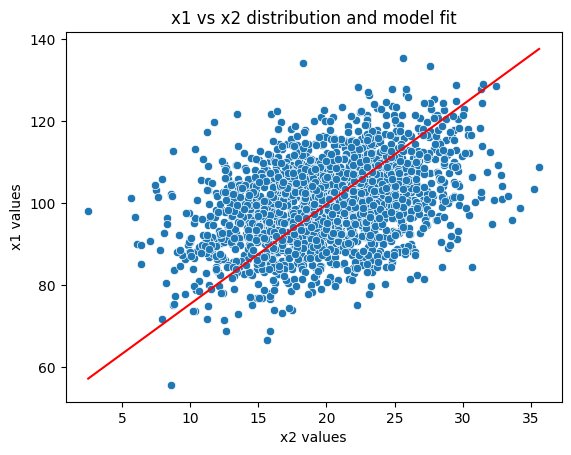

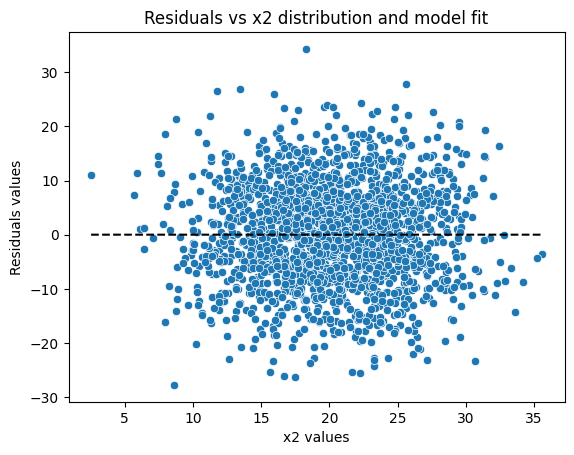

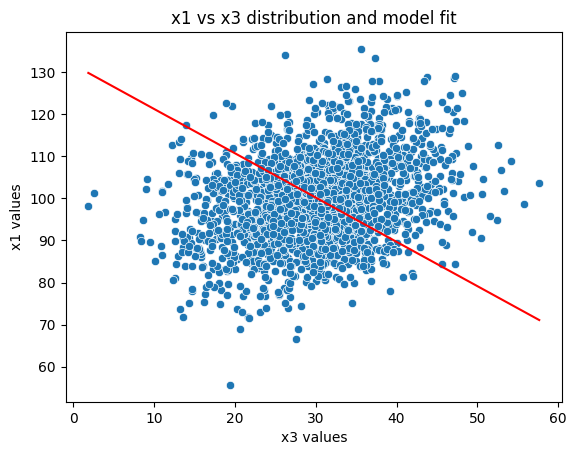

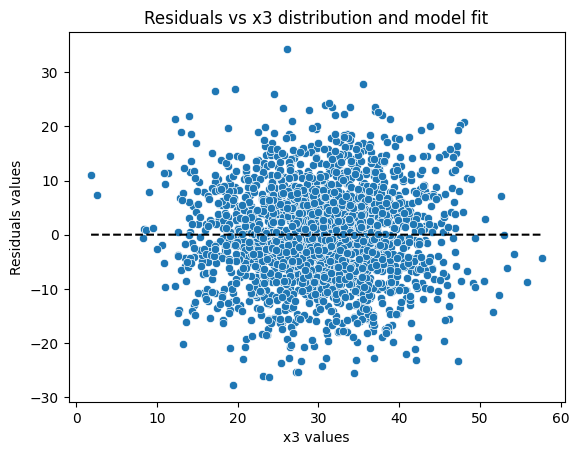

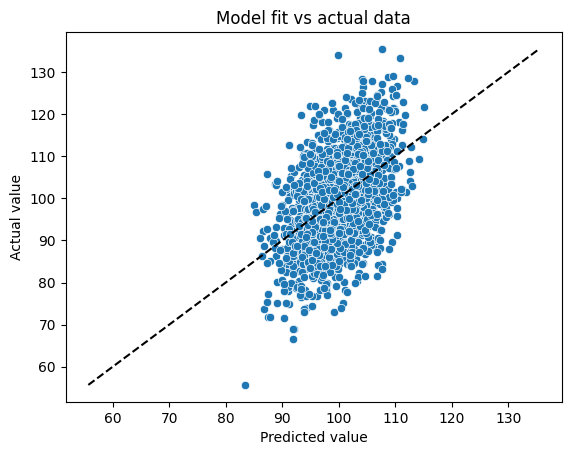

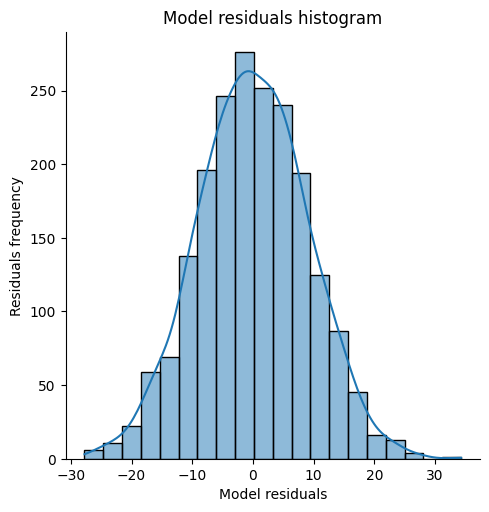

,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.968939,True,0.999595,,,gaussian distribution
1,Epps-Pulley test,0.95,0.05,-,-,-,-,False,count more than 1000
2,D'Agostino's K-squared test,0.95,0.05,0.922085,True,0.162235,,,gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,0.114962,0.785,True,gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.999852,True,0.007468,,,gaussian distribution
5,Lilliefors test,0.95,0.05,0.99,True,0.007409,,,gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.999334,True,0.016117,,,gaussian distribution
7,Chi-squared test,0.95,0.05,1.0,True,-281474976710656000000.0,,,gaussian distribution
8,Jarque–Bera test,0.95,0.05,0.898002,True,0.215166,,,gaussian distribution
9,skewtest,0.95,0.05,0.839566,True,0.202449,,,gaussian distribution


In [25]:
# Проверяем результат руками...
dt_collinearity_test, model_collinearity_test = train_model(dt_collinearity, target='x1', feature_names=['x2', 'x3'], show_results=True, return_norm_tests=True)

In [26]:
# Считаем VIF для первого регрессора руками 
1 / (1 - model_collinearity_test.rsquared)

1.2848833175941374

## 3. Гетероскедастичность
При гетероскедастичности в модели мы более не можем использовать классические формулы расчета коэффициентов и должны применять формулу робастных ошибок

In [28]:
# Определим параметры выборки для задачи гетероскедастичности
# Создадим удобный словарь, чтобы передавать его в функцию
dist_params = dict(

    # Зададим параметры распределения факторов
    x1_mean = 100.0,
    x1_std = 10.0,
    x2_mean = 20.0,
    x2_std = 5.0,
    corr_12 = 0.0,
    
    # Зададим параметры распределения ошибки
    e_mean = 0.0,
    e_std = 100.0,

    # Укажем размер выборки
    N = 100,

    # Зададим действительные параметры модели
    beta0 = 500.0,
    beta1 = 6.7,
    beta2 = 2.3,
)

# Установим стартовую точку для алгоритма генерации случайных чисел
RANDOM_SEED = 42

,x1,x2,y,e
0,104.967142,19.308678,1288.038362,40.348554
1,106.476885,27.615149,1341.983291,65.073315
2,97.658466,18.829315,1303.341068,105.721919
3,115.792128,23.837174,1475.247760,144.615002
4,95.305256,22.712800,1062.706537,-128.078120
...,...,...,...,...
95,95.534850,24.281994,1131.203447,-64.728638
96,102.140937,13.771306,1312.078886,96.060601
97,101.731809,21.926587,1264.585821,32.551549
98,91.161426,20.768626,1227.690340,69.140949


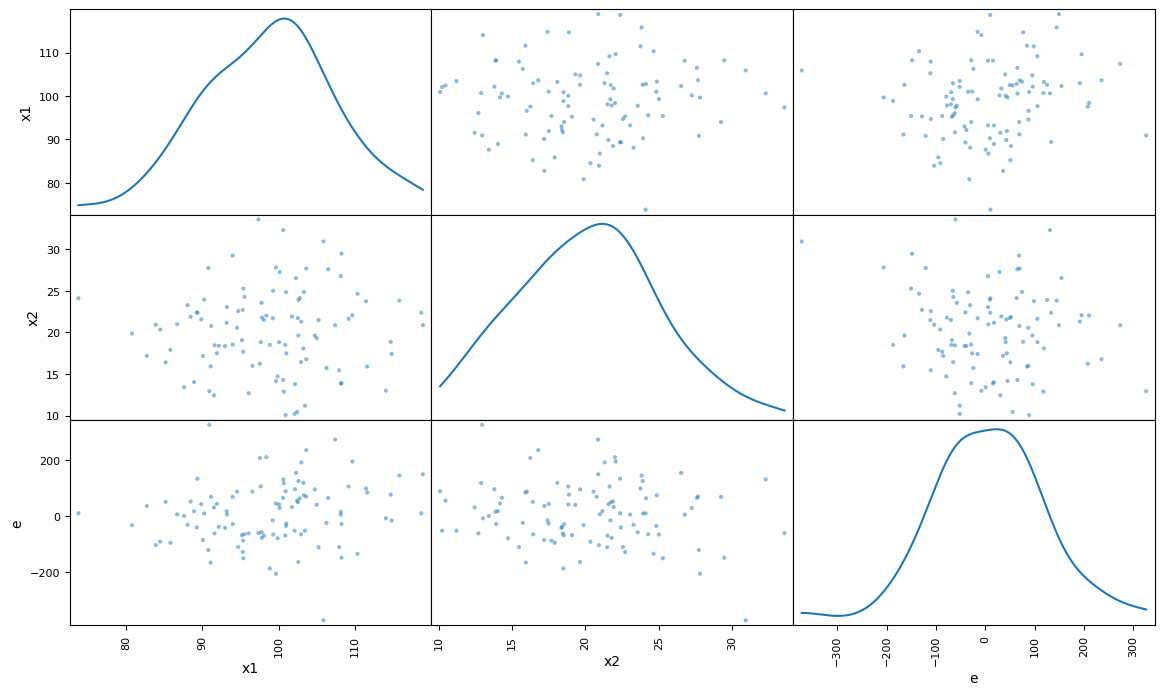

In [29]:
# Сгенерируем датасет, в котором исперсия ошибки будет скоррелирована с одним из регрессоров (пусть это будет регрессор х1)
dt_heteroskedasticity = gen_data(y_type='heteroskedasticity', params=dist_params, seed=RANDOM_SEED)

display(dt_heteroskedasticity)

# Посмотрим на корреляции глазами
pd.plotting.scatter_matrix(dt_heteroskedasticity[['x1', 'x2', 'e']], figsize = (14,8), diagonal = 'kde');

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     24.37
Date:                Thu, 13 Feb 2025   Prob (F-statistic):           2.66e-09
Time:                        13:07:21   Log-Likelihood:                -608.68
No. Observations:                 100   AIC:                             1223.
Df Residuals:                      97   BIC:                             1231.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        364.1142    132.040      2.758      0.0

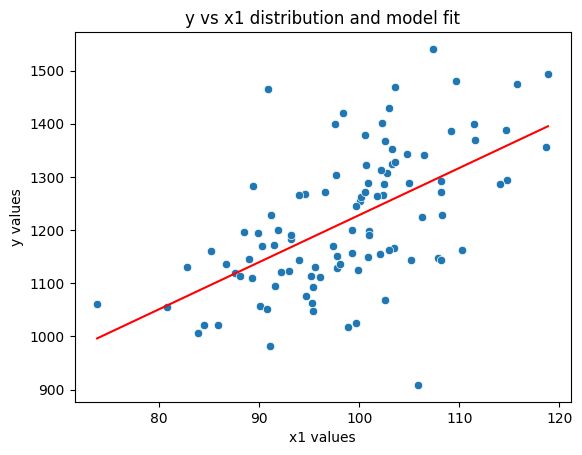

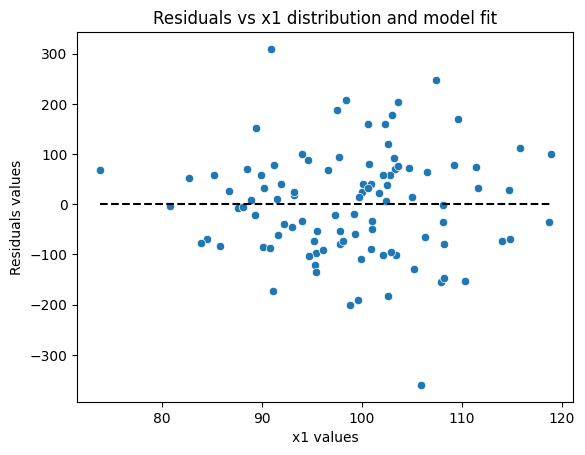

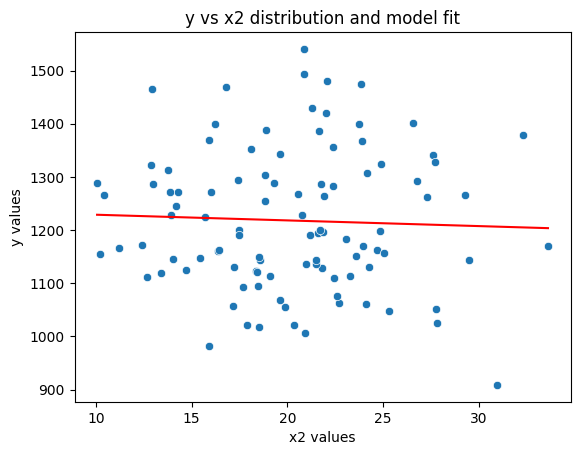

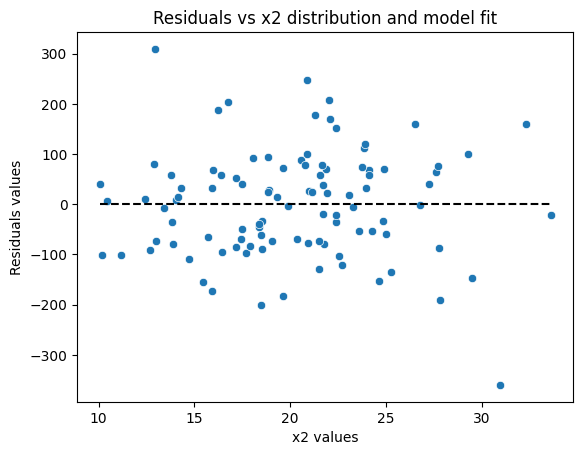

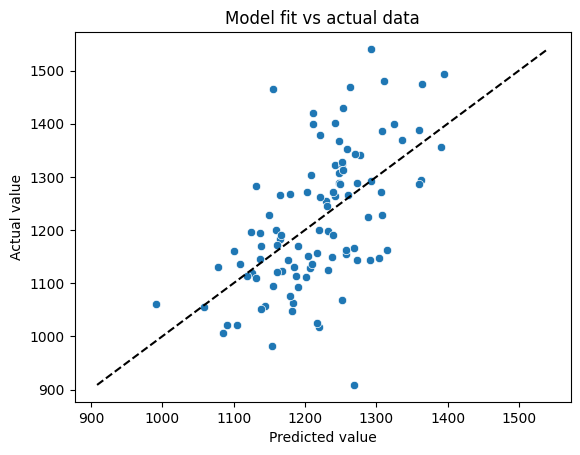

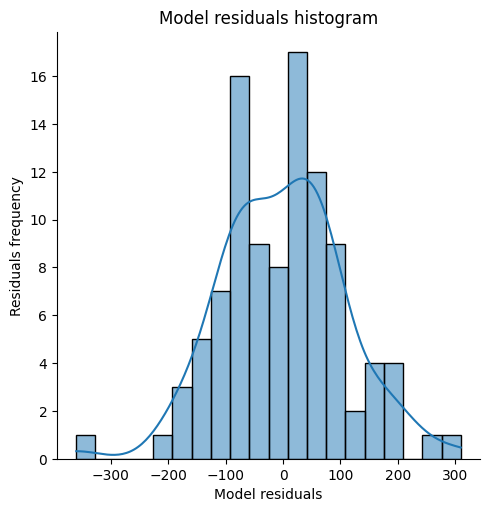

,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.445676,True,0.987119,,,gaussian distribution
1,Epps-Pulley test,0.95,0.05,0.662537,True,0.063814,0.376,True,gaussian distribution
2,D'Agostino's K-squared test,0.95,0.05,0.286198,True,2.502142,,,gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,0.371132,0.759,True,gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.892112,True,0.056233,,,gaussian distribution
5,Lilliefors test,0.95,0.05,0.578085,True,0.057368,,,gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.864508,True,0.052101,,,gaussian distribution
7,Chi-squared test,0.95,0.05,1.0,True,-12867427506772842496.0,,,gaussian distribution
8,Jarque–Bera test,0.95,0.05,-,-,-,,,count less than 2000
9,skewtest,0.95,0.05,0.998941,True,-0.001327,,,gaussian distribution


In [30]:
# Строим OLS модель с обычной матрицей ошибок
dt_heteroskedasticity, model_heteroskedasticity = train_model(
    dt_heteroskedasticity, target='y', feature_names=['x1', 'x2'], show_results=True, return_norm_tests=True)

##### Прогоняем тесты на гетероскедастичность 

In [31]:
# Тест Вайта
from statsmodels.stats.diagnostic import het_white

# Получаем результаты теста
white_test = het_white(model_heteroskedasticity.resid, model_heteroskedasticity.model.exog)

labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, white_test)))

{'Test Statistic': 12.072336552678287, 'Test Statistic p-value': 0.033809934144981145, 'F-Statistic': 2.5812118540637163, 'F-Test p-value': 0.031104591984117455}


In [32]:
# Тест Голдфельда-Квандта
from statsmodels.stats.diagnostic import het_goldfeldquandt

# ------------ Реализовать тест в качестве домашнего задания ------------------

Немного о настройках для [Statsmodels](https://www.statsmodels.org/devel/generated/statsmodels.regression.linear_model.RegressionResults.get_robustcov_results.html#statsmodels.regression.linear_model.RegressionResults.get_robustcov_results)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.05247
Date:                Thu, 13 Feb 2025   Prob (F-statistic):              0.819
Time:                        13:07:47   Log-Likelihood:                -629.02
No. Observations:                 100   AIC:                             1262.
Df Residuals:                      98   BIC:                             1267.
Df Model:                           1                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1229.6160     49.954     24.615      0.0

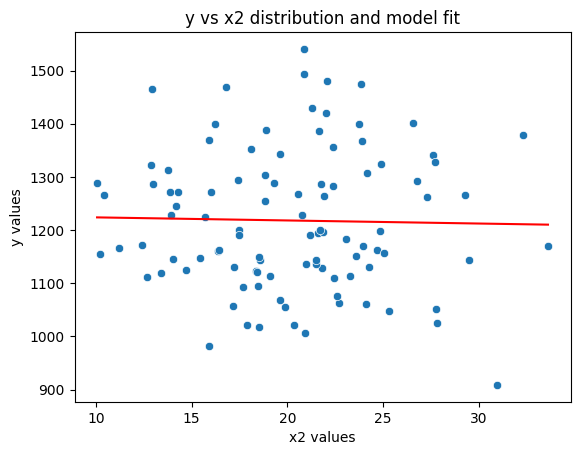

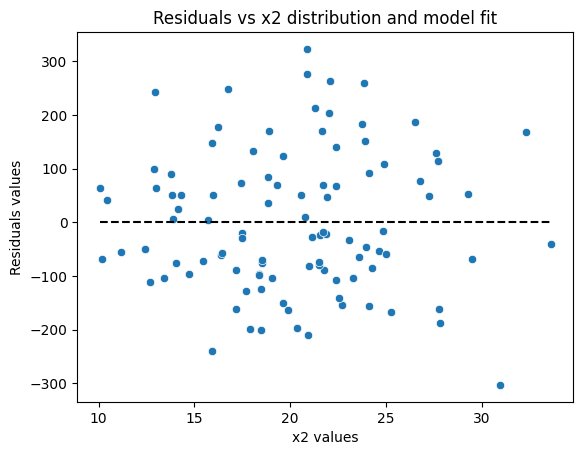

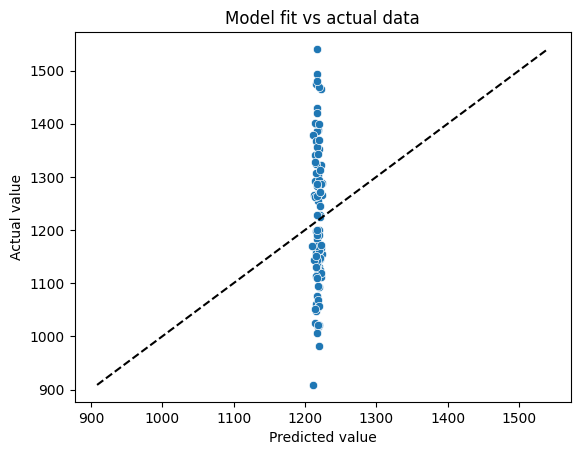

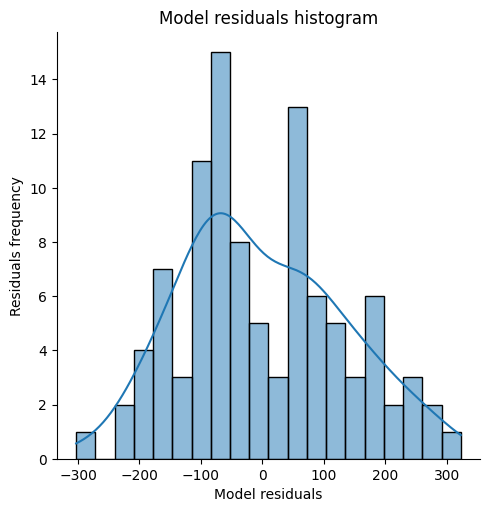

,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.192917,True,0.982095,,,gaussian distribution
1,Epps-Pulley test,0.95,0.05,0.072825,True,0.334196,0.376,True,gaussian distribution
2,D'Agostino's K-squared test,0.95,0.05,0.254245,True,2.738916,,,gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,0.690187,0.759,True,gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.367428,True,0.090241,,,gaussian distribution
5,Lilliefors test,0.95,0.05,0.046278,False,0.08999,,,not gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.44686,True,0.132882,,,gaussian distribution
7,Chi-squared test,0.95,0.05,1.0,True,-1513815000796804864.0,,,gaussian distribution
8,Jarque–Bera test,0.95,0.05,-,-,-,,,count less than 2000
9,skewtest,0.95,0.05,0.214217,True,1.242053,,,gaussian distribution


In [33]:
# Оцениваем регрессию с применением робастных ошибок
dt_heteroskedasticity, model_heteroskedasticity = train_model(
    dt_heteroskedasticity, target='y', feature_names=['x2'], show_results=True, return_norm_tests=True, robust=True)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     39.65
Date:                Thu, 13 Feb 2025   Prob (F-statistic):           2.61e-13
Time:                        13:08:14   Log-Likelihood:                -608.68
No. Observations:                 100   AIC:                             1223.
Df Residuals:                      97   BIC:                             1231.
Df Model:                           2                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        364.1142    127.645      2.853      0.0

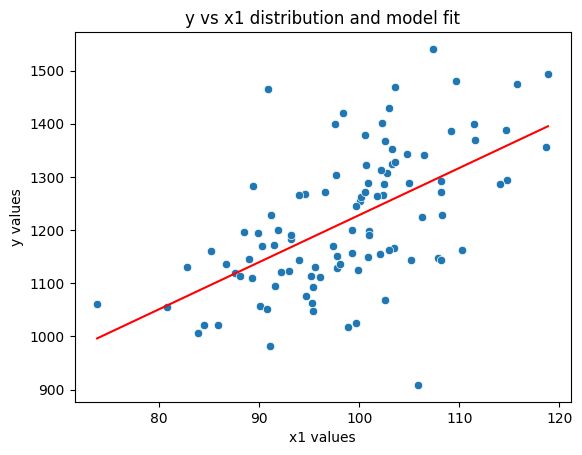

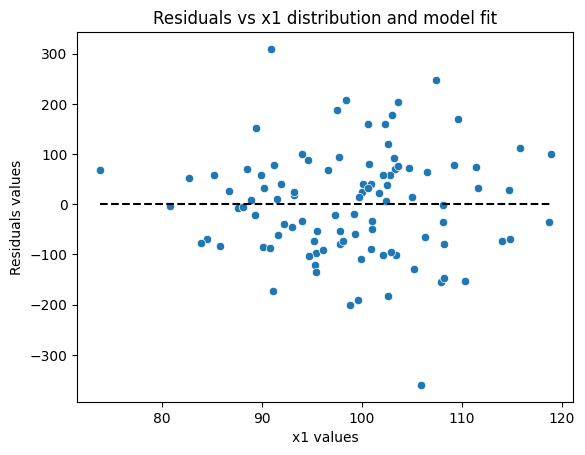

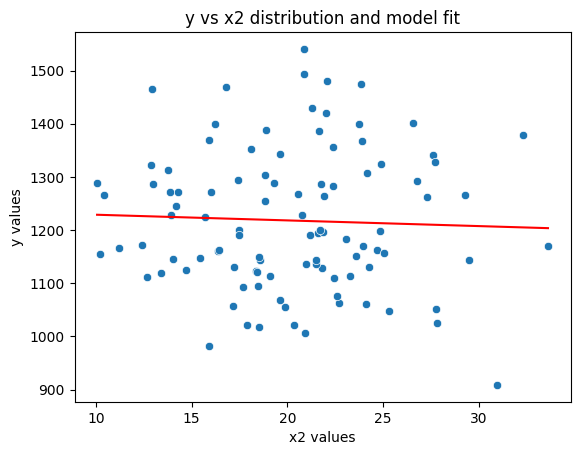

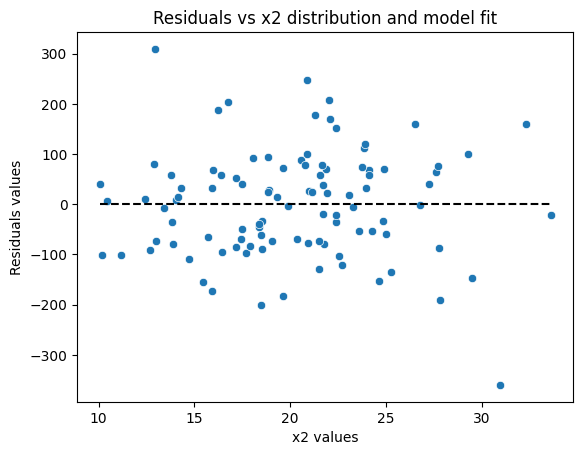

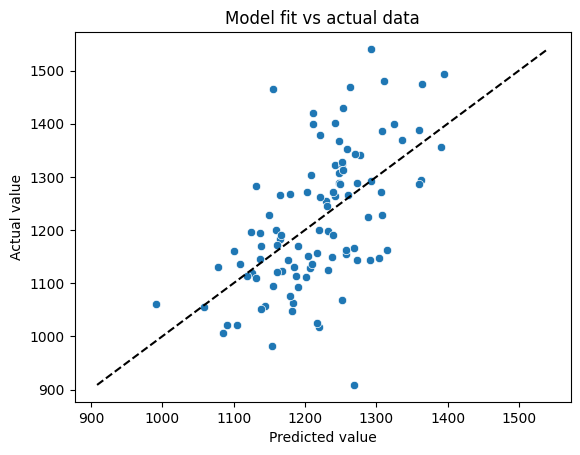

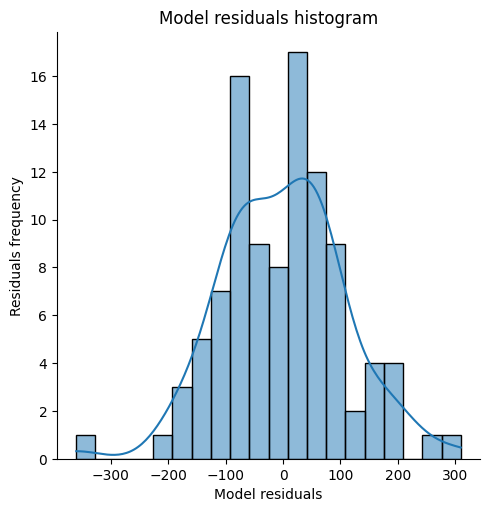

,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.445676,True,0.987119,,,gaussian distribution
1,Epps-Pulley test,0.95,0.05,0.662537,True,0.063814,0.376,True,gaussian distribution
2,D'Agostino's K-squared test,0.95,0.05,0.286198,True,2.502142,,,gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,0.371132,0.759,True,gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.892112,True,0.056233,,,gaussian distribution
5,Lilliefors test,0.95,0.05,0.578085,True,0.057368,,,gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.864508,True,0.052101,,,gaussian distribution
7,Chi-squared test,0.95,0.05,1.0,True,-12867427506772842496.0,,,gaussian distribution
8,Jarque–Bera test,0.95,0.05,-,-,-,,,count less than 2000
9,skewtest,0.95,0.05,0.998941,True,-0.001327,,,gaussian distribution


In [35]:
# Оцениваем регрессию с применением робастных ошибок
dt_heteroskedasticity, model_heteroskedasticity = train_model(
    dt_heteroskedasticity, target='y', feature_names=['x1', 'x2'], show_results=True, return_norm_tests=True, robust=True)

In [36]:
# Тест Вайта
from statsmodels.stats.diagnostic import het_white

# Получаем результаты теста
white_test = het_white(model_heteroskedasticity.resid, model_heteroskedasticity.model.exog)

labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, white_test)))

{'Test Statistic': 12.072336552678287, 'Test Statistic p-value': 0.033809934144981145, 'F-Statistic': 2.5812118540637163, 'F-Test p-value': 0.031104591984117455}


## 4. Мультиколлинеарность
При мультиколлинеарности несколько регрессоров в модели имеют ненулевую корреляцию друг с другом